# Installing Streamlit, Pandas, Numpy and pyngrok

In [ ]:
!pip install streamlit scikit-learn pandas numpy pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 57.8 MB/s eta 0:00:00


# Importing Python Libraries and Models

In [ ]:
%%writefile backend.py
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Writing backend.py


# **Loading Dataset**


In [ ]:
print("Loading Dataset...")
data = "heart.csv"
print("Heart Dataset successfully loaded")

Loading Dataset...
Heart Dataset successfully loaded


# Exploratory Data Analysis

In [ ]:
import pandas as pd
data = pd.read_csv("heart.csv")
print("\n===== BASIC INFO =====")
print("\nMissing Values:\n", data.isnull().sum())
print("\nClass Distribution:\n", data["target"].value_counts())
print("\nCorrelation with Target:\n")
print(data.corr()["target"].sort_values(ascending=False))


===== BASIC INFO =====

Missing Values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Class Distribution:
 target
1    526
0    499
Name: count, dtype: int64

Correlation with Target:

target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64


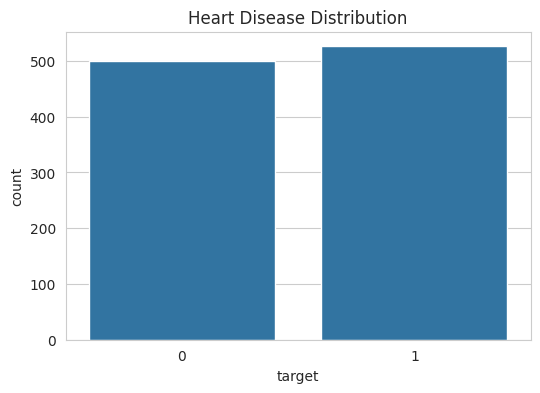

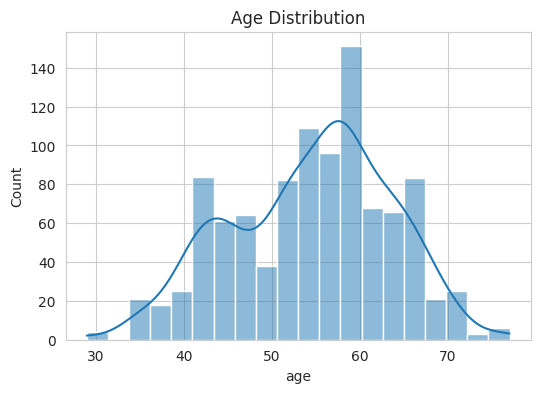

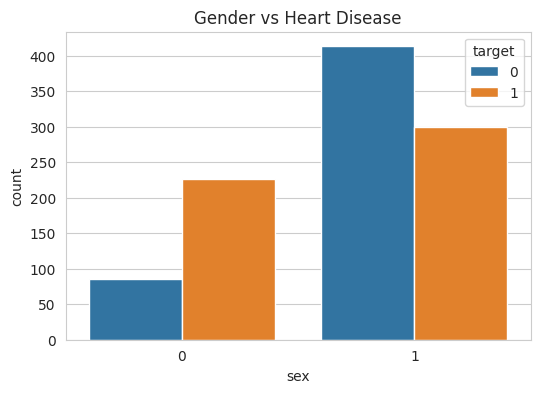

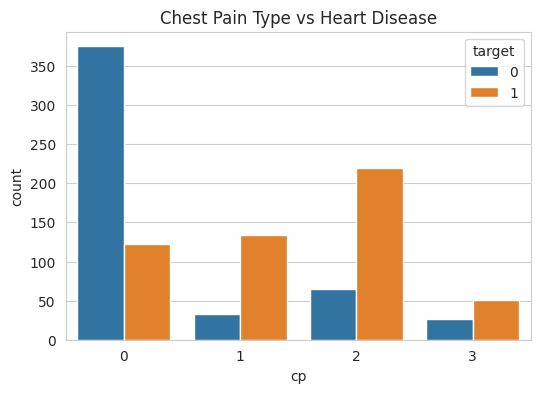

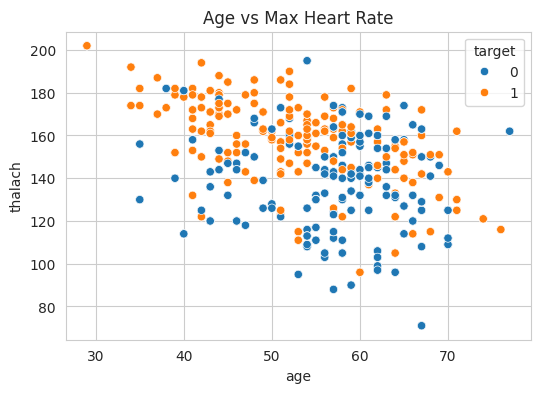

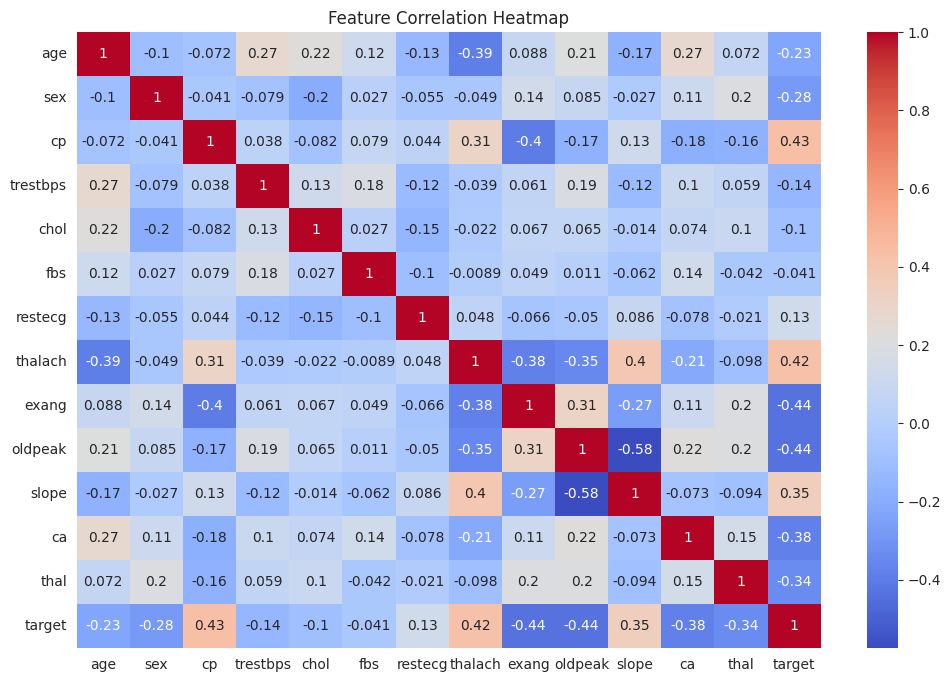

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 1️⃣ Target Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=data)
plt.title("Heart Disease Distribution")
plt.show()


# 2️⃣ Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(data['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()


# 3️⃣ Gender vs Heart Disease
plt.figure(figsize=(6,4))
sns.countplot(x='sex', hue='target', data=data)
plt.title("Gender vs Heart Disease")
plt.show()


# 4️⃣ Chest Pain Type vs Target
plt.figure(figsize=(6,4))
sns.countplot(x='cp', hue='target', data=data)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()


# 5️⃣ Age vs Max Heart Rate
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='thalach', hue='target', data=data)
plt.title("Age vs Max Heart Rate")
plt.show()


# 6️⃣ Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# Feature and Target Splitting

In [ ]:
X = data.drop("target", axis=1)
y = data["target"]
df = pd.read_csv("heart.csv")
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


# Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standard Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Data Modelling

Model Performance Comparison:



,Model,Accuracy,Precision,Recall,F1-Score,AUC,Time (s)
0,Random Forest,0.970732,0.955036,0.976443,0.970874,0.997144,0.657453
1,XGBoost,0.941463,0.939274,0.959888,0.940594,0.984009,0.102425
2,Decision Tree,0.829268,0.852593,0.924482,0.844444,0.900057,0.003772
3,Logistic Regression,0.795122,0.824850,0.900672,0.810811,0.878736,0.012896
4,SVM,0.887805,0.912316,0.936303,0.894009,0.963164,0.122030


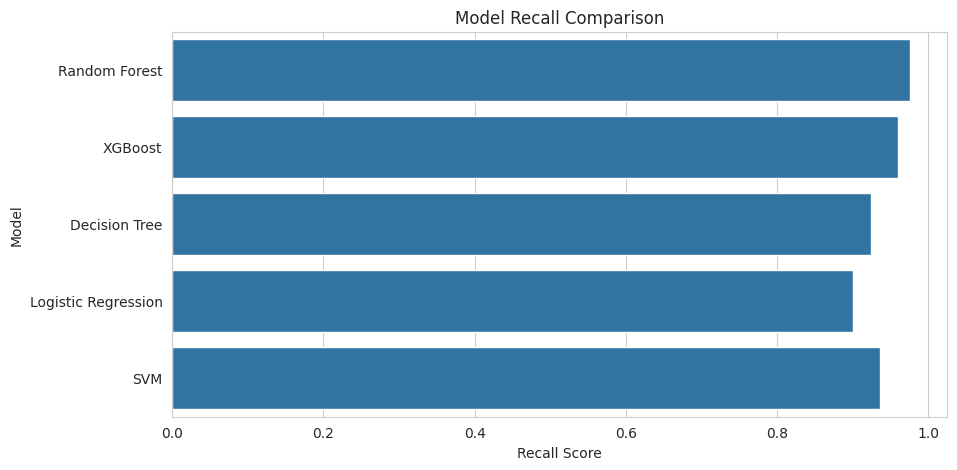


Final Model Selection Based on Highest Recall

Selected Model: Random Forest
Recall Score: 0.976443


In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier


models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=120,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.7,
        colsample_bytree=0.7,
        eval_metric='logloss',
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=6,
        min_samples_leaf=3,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "SVM": SVC(probability=True)
}

results = []

for name, model in models.items():
    start = time.time()

    # train on scaled data
    model.fit(X_train_scaled, y_train)

    end = time.time()

    # predict on scaled data
    y_pred = model.predict(X_test_scaled)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    precision = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="precision").mean()
    recall = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="recall").mean()
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    train_time = end - start

    results.append([name, accuracy, precision, recall, f1, auc, train_time])

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC", "Time (s)"
])

results_df = results_df.round(6)

print("Model Performance Comparison:\n")
display(results_df)

plt.figure(figsize=(10,5))
sns.barplot(x="Recall", y="Model", data=results_df)
plt.title("Model Recall Comparison")
plt.xlabel("Recall Score")
plt.ylabel("Model")
plt.show()

best_model = results_df.loc[results_df["Recall"].idxmax()]

print("\nFinal Model Selection Based on Highest Recall\n")
print("Selected Model:", best_model["Model"])
print("Recall Score:", best_model["Recall"])

In [ ]:
import pickle

selected_model_name = best_model["Model"]
final_model = models[selected_model_name]
final_model.fit(X_train_scaled, y_train)

pickle.dump(final_model, open("best_heart_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("✅ best_heart_model.pkl saved")
print("✅ scaler.pkl saved")
print("✅ Final selected model:", selected_model_name)

✅ best_heart_model.pkl saved
✅ scaler.pkl saved
✅ Final selected model: Random Forest


# Running backend python code

In [ ]:
!python backend.py

# Front-End code : App.py

In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import pickle
import datetime

st.set_page_config(page_title="Multi Disease Prediction", layout="centered")

if "registered" not in st.session_state:
    st.session_state.registered = False

if not st.session_state.registered:   # Registration Page

    st.title("📋 Patient Registration")
    st.write("Please enter your details before proceeding to the prediction system.")

    col1, col2 = st.columns(2)

    with col1:
        patient_id = st.text_input("Patient ID *", "19783")
        full_name = st.text_input("Full Name *", "Yash Pandey")
        age = st.number_input("Age", 1, 120, 25)

    with col2:
        gender = st.selectbox("Gender", ["Male", "Female"])
        contact = st.text_input("Contact Number *", "1234567893")
        visit_date = st.date_input("Date of Visit", datetime.date.today())

    if st.button("Proceed to Prediction →"):

        st.session_state.patient_id = patient_id
        st.session_state.full_name = full_name
        st.session_state.age = age
        st.session_state.gender = gender
        st.session_state.visit_date = visit_date

        st.session_state.registered = True
        st.rerun()

else:

    st.title("🩺 Multi Disease Prediction System")

    st.info(
        f"{st.session_state.full_name} | "
        f"ID: {st.session_state.patient_id} | "
        f"Age: {st.session_state.age} | "
        f"{st.session_state.gender} | "
        f"{st.session_state.visit_date}"
    )

    model = pickle.load(open("best_heart_model.pkl", "rb"))
    scaler = pickle.load(open("scaler.pkl", "rb"))

    disease_type = st.radio(
        "Select Disease",
        ["Heart Disease", "Kidney Disease", "Diabetes"],
        horizontal=True
    )

    st.markdown("---")

    if disease_type == "Heart Disease":

        st.subheader("❤️ Heart Disease Prediction")
        st.info("Valid Age Range: 16 - 90 Years")

        col1, col2 = st.columns(2)

        with col1:
            age = st.number_input("Age", 16, 90, 30)
            gender = st.selectbox("Gender", ["Male", "Female"])
            chest_pain = st.selectbox(
                "Chest Pain Type",
                ["Typical Angina", "Atypical Angina",
                 "Non-anginal Pain", "Asymptomatic"]
            )
            resting_bp = st.number_input("Resting BP", 80, 250, 120)
            cholesterol = st.number_input("Cholesterol", 100, 600, 200)
            fasting_bs = st.selectbox("Fasting Blood Sugar > 120 mg/dl", ["True", "False"])
            rest_ecg = st.selectbox(
                "Rest ECG",
                ["Normal", "ST-T Abnormality", "LV Hypertrophy"]
            )

        with col2:
            max_hr = st.number_input("Max Heart Rate", 60, 220, 150)
            exang = st.selectbox("Exercise Induced Angina", ["Yes", "No"])
            oldpeak = st.number_input("Oldpeak", 0.0, 10.0, 1.0)
            slope = st.selectbox("ST Slope", ["Upsloping", "Flat", "Downsloping"])
            ca = st.number_input("Number of Major Vessels (0-4)", 0, 4, 0)
            thal = st.selectbox(
                "Thalassemia",
                ["Normal", "Fixed Defect", "Reversible Defect"]
            )

        if st.button("Predict"):

            gender = 1 if gender == "Male" else 0

            cp_map = {
                "Typical Angina": 0,
                "Atypical Angina": 1,
                "Non-anginal Pain": 2,
                "Asymptomatic": 3
            }
            chest_pain = cp_map[chest_pain]

            fasting_bs = 1 if fasting_bs == "True" else 0

            restecg_map = {
                "Normal": 0,
                "ST-T Abnormality": 1,
                "LV Hypertrophy": 2
            }
            rest_ecg = restecg_map[rest_ecg]

            exang = 1 if exang == "Yes" else 0

            slope_map = {
                "Upsloping": 0,
                "Flat": 1,
                "Downsloping": 2
            }
            slope = slope_map[slope]

            thal_map = {
                "Normal": 1,
                "Fixed Defect": 2,
                "Reversible Defect": 3
            }
            thal = thal_map[thal]

            input_data = np.array([[age, gender, chest_pain,
                                    resting_bp, cholesterol,
                                    fasting_bs, rest_ecg,
                                    max_hr, exang, oldpeak,
                                    slope, ca, thal]])

            input_scaled = scaler.transform(input_data)
            result = model.predict(input_scaled)

            if result[0] == 1:
                st.error("⚠ High Risk of Heart Disease")
            else:
                st.success("✅ Low Risk of Heart Disease")

    elif disease_type == "Kidney Disease":
        st.subheader("🩸 Kidney Disease Prediction")
        st.warning("Backend under development.")

    elif disease_type == "Diabetes":
        st.subheader("🧪 Diabetes Prediction")
        st.warning("Backend under development.")

    st.markdown("---")
    st.markdown(
        "<div style='text-align:center;'>"
        "<b>Capstone Project 2026 ( Btech CSE )</b><br>"
        "DIT UNIVERSITY , Dehradun<br>"
        "Developed by Abhyudita Pandey | Nishka Sharma | Raghav Sharma"
        "</div>",
        unsafe_allow_html=True
    )

Writing app.py


# Running Streamlit..

In [ ]:
!pkill -f streamlit
from pyngrok import ngrok
ngrok.kill()

!nohup streamlit run app.py --server.port 8501 --server.headless true > streamlit.log 2>&1 &


# Connecting to NGROK

In [ ]:
import time
time.sleep(10)

!ngrok config add-authtoken 32OIzXWdRpHfPhXZWWpP4UPSYBw_7enQUgvMy5xc7o9mUdEYG
public_url = ngrok.connect(8501)
public_url

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


<NgrokTunnel: "https://12af-34-106-15-77.ngrok-free.app" -> "http://localhost:8501">